# Analyse des scores de netteté



In [6]:
# Importer les bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pour afficher les graphiques dans le notebook
%matplotlib inline

In [7]:
# Charger le fichier CSV des scores
scores = pd.read_csv('resultats_scores_nettete.csv')
scores.head()

,image1,image2,metrique,window_size,score1,score2
0,p27a,p27b,Laplacian (LAP2),5,12.332358,3.846931
1,p27a,p27b,Variance of Laplacian (LAP4),5,793.535784,44.853878
2,p27a,p27b,Gray-level Variance (STA3),5,90.127094,14.015947
3,p27a,p27b,Laplacian (LAP2),7,12.343067,3.843378
4,p27a,p27b,Variance of Laplacian (LAP4),7,790.421511,47.647927


## Afficher l'histogramme des scores de netteté pour chaque taille de fenêtre

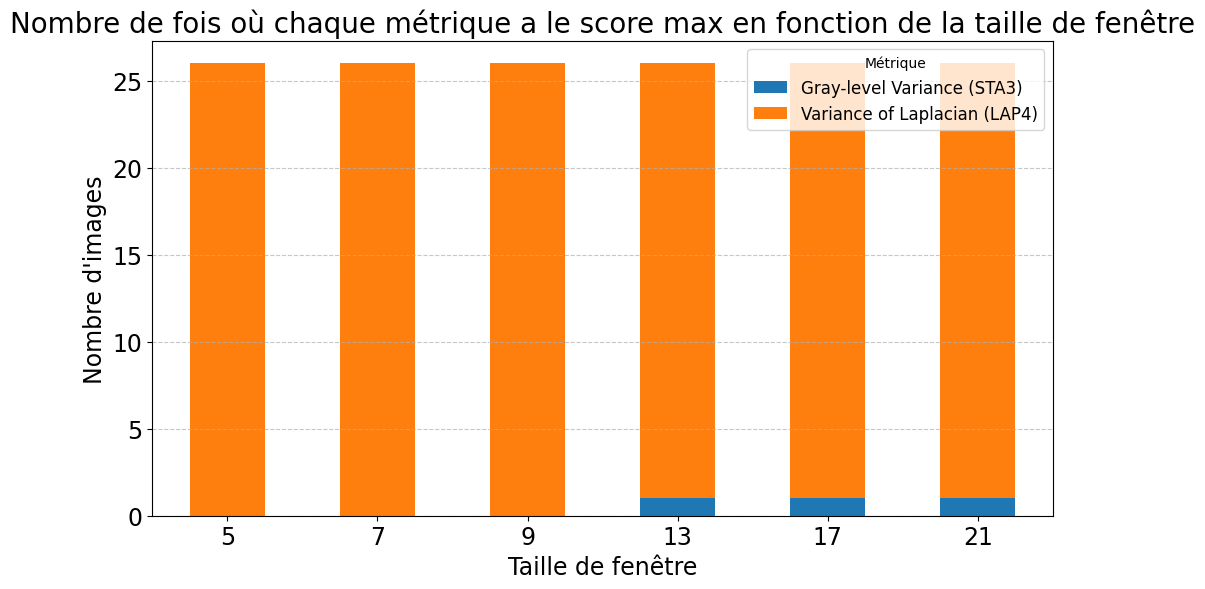

In [36]:
# Pour chaque image, chaque taille de fenêtre, et chaque métrique, on prend le score maximal entre score1 et score2
scores['score_max'] = scores[['score1', 'score2']].max(axis=1)

# Pour chaque image et chaque taille de fenêtre, trouver la métrique qui a le score_max le plus élevé
idx2 = scores.groupby(['image1', 'image2', 'window_size'])['score_max'].idxmax()
max_scores2 = scores.loc[idx2]
# Compter la fréquence de chaque métrique comme "meilleure" selon la taille de fenêtre
freq2 = max_scores2.groupby(['window_size', 'metrique']).size().unstack(fill_value=0)

# Afficher la fréquence de chaque métrique choisie comme la meilleure
freq2.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Nombre de fois où chaque métrique a le score max en fonction de la taille de fenêtre",fontsize=20)
plt.xlabel("Taille de fenêtre",fontsize=17)
plt.ylabel("Nombre d'images",fontsize=17)
plt.legend(title='Métrique',fontsize=12)
plt.xticks(rotation=0, fontsize=17)
plt.yticks(fontsize=17)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
print(freq2)

metrique     Gray-level Variance (STA3)  Variance of Laplacian (LAP4)
window_size                                                          
5                                     0                            26
7                                     0                            26
9                                     0                            26
13                                    1                            25
17                                    1                            25
21                                    1                            25
